# EDA новых фичей — train_data_v2.csv

Анализ 86 новых признаков, добавленных в датасет:
- **OSM POI (76 фичей):** офисы, платёжные терминалы, переводы, магазины, гипермаркеты, рынки, фитнес, отели, ж/д, жильё, АЗС, пешеходные зоны, тип земли, центр города
- **Экономика регионов/городов (10 фичей):** население, тип города, ВРП, зарплаты, доходы, округ, макрорегион

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

df = pd.read_csv('../data/train_data_v2.csv')
print(f'Размер датасета: {df.shape}')

# Список новых колонок (всё что не было в train_data.csv)
OLD_COLS = [
    'id', 'atm_group', 'address_raw', 'address_geocoded', 'geo_lon', 'geo_lat',
    'country', 'region', 'municipality', 'city', 'street', 'house',
    'population_density_per_km2', 'target',
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement',
    'access_for_disabled', 'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'nearest_malls_dist_m', 'count_malls_300m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'nearest_cafes_dist_m', 'count_cafes_300m',
    'nearest_restaurants_dist_m', 'count_restaurants_300m',
    'nearest_public_transport_dist_m', 'count_public_transport_300m',
    'nearest_parking_dist_m', 'count_parking_300m',
    'nearest_education_dist_m', 'count_education_300m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'count_post_offices_300m', 'has_subway_nearby'
]

NEW_COLS = [c for c in df.columns if c not in OLD_COLS]
print(f'Новых колонок: {len(NEW_COLS)}')

# Разбивка по группам
POI_DIST_COLS = [c for c in NEW_COLS if c.startswith('nearest_') and c.endswith('_dist_m')]
POI_COUNT_300 = [c for c in NEW_COLS if 'count_' in c and '_300m' in c]
POI_COUNT_100 = [c for c in NEW_COLS if 'count_' in c and '_100m' in c]
LAND_COLS     = ['land_use_type', 'land_use_dist_m', 'city_center_dist_m', 'is_city_center']
ECON_NUM_COLS = ['population', 'grp_per_capita_2023_rub', 'avg_salary_oct_2025_rub', 'avg_income_q3_2025_rub']
ECON_CAT_COLS = ['city_type', 'city_size_category', 'federal_district', 'macro_region']
ECON_BIN_COLS = ['is_federal_city', 'is_federal_district_capital']

TARGET = 'target'
print(f'\nДистанционных фичей: {len(POI_DIST_COLS)}')
print(f'Счётчиков @300м: {len(POI_COUNT_300)}')
print(f'Счётчиков @100м: {len(POI_COUNT_100)}')

Размер датасета: (6200, 134)
Новых колонок: 87

Дистанционных фичей: 15
Счётчиков @300м: 15
Счётчиков @100м: 15


## 1. Общий обзор датасета

Новых фичей с пропусками: 20/87
Новых фичей без пропусков: 67/87


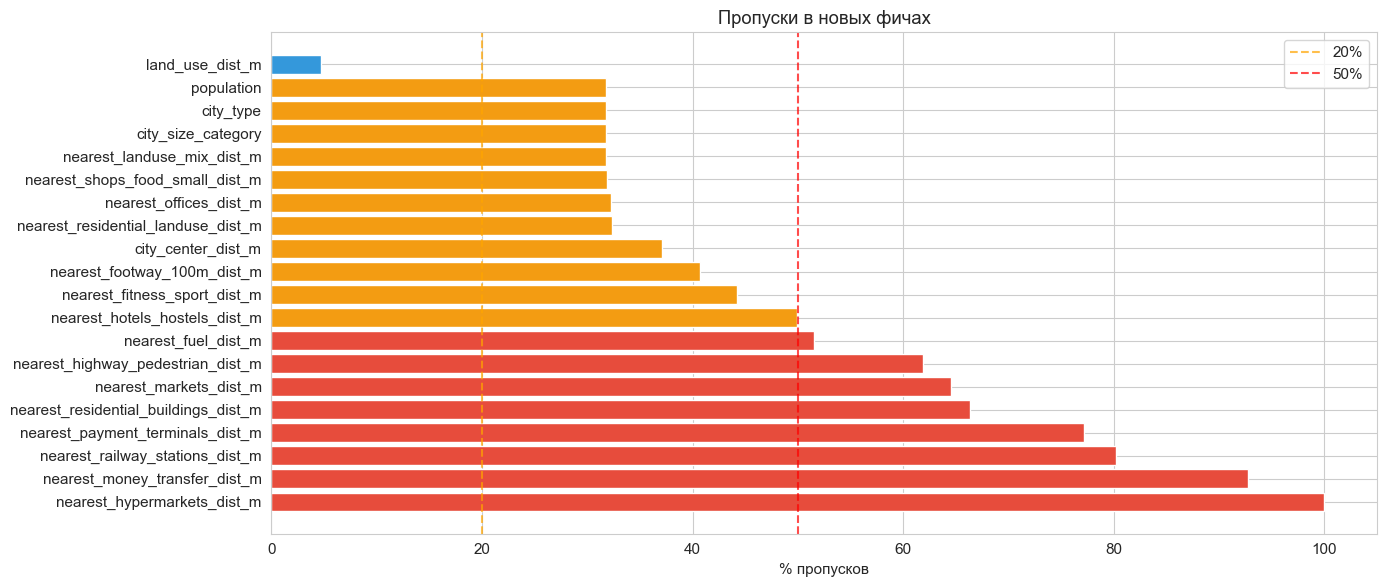

,feature,missing_%
0,nearest_hypermarkets_dist_m,100.000000
1,nearest_money_transfer_dist_m,92.741935
2,nearest_railway_stations_dist_m,80.209677
3,nearest_payment_terminals_dist_m,77.209677
4,nearest_residential_buildings_dist_m,66.322581
5,nearest_markets_dist_m,64.500000
6,nearest_highway_pedestrian_dist_m,61.887097
7,nearest_fuel_dist_m,51.532258
8,nearest_hotels_hostels_dist_m,49.903226
9,nearest_fitness_sport_dist_m,44.177419


In [2]:
# Пропуски по новым фичам
missing = df[NEW_COLS].isnull().mean().sort_values(ascending=False) * 100
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['feature', 'missing_%']

print(f'Новых фичей с пропусками: {len(missing_df)}/{len(NEW_COLS)}')
print(f'Новых фичей без пропусков: {(missing == 0).sum()}/{len(NEW_COLS)}')

fig, ax = plt.subplots(figsize=(14, max(4, len(missing_df) * 0.3)))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#3498db' for v in missing_df['missing_%']]
ax.barh(missing_df['feature'], missing_df['missing_%'], color=colors)
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20%')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50%')
ax.set_xlabel('% пропусков')
ax.set_title('Пропуски в новых фичах')
ax.legend()
plt.tight_layout()
plt.show()

display(missing_df.style.background_gradient(cmap='YlOrRd', subset=['missing_%']))

## 2. Тип земельного использования и центр города

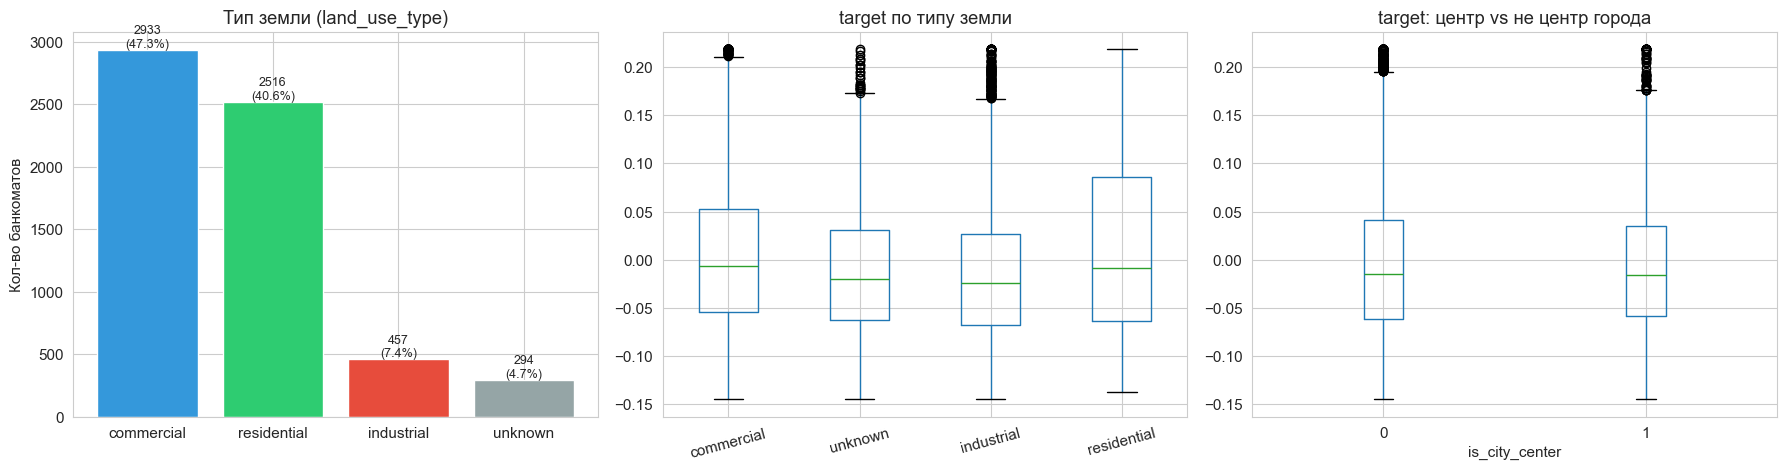

Медианный target по типу земли:
               median    mean  count
land_use_type                       
commercial    -0.0067  0.0098   2933
industrial    -0.0203 -0.0032    457
residential   -0.0241 -0.0103   2516
unknown       -0.0088  0.0130    294

Медианный target: центр города vs нет:
                median    mean  count
is_city_center                       
0              -0.0154  0.0014   5122
1              -0.0157 -0.0018   1078


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# land_use_type распределение
lut_counts = df['land_use_type'].value_counts()
axes[0].bar(lut_counts.index, lut_counts.values, color=['#3498db','#2ecc71','#e74c3c','#95a5a6'])
axes[0].set_title('Тип земли (land_use_type)')
axes[0].set_ylabel('Кол-во банкоматов')
for i, (k, v) in enumerate(lut_counts.items()):
    axes[0].text(i, v + 20, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# land_use_type vs target
order = df.groupby('land_use_type')['target'].median().sort_values(ascending=False).index
df.boxplot(column='target', by='land_use_type', ax=axes[1], 
           positions=range(len(order)), notch=False)
axes[1].set_xticklabels(order, rotation=15)
axes[1].set_title('target по типу земли')
axes[1].set_xlabel('')
plt.suptitle('')

# is_city_center vs target
df.boxplot(column='target', by='is_city_center', ax=axes[2])
axes[2].set_title('target: центр vs не центр города')
axes[2].set_xlabel('is_city_center')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Медианный target по типу земли:')
print(df.groupby('land_use_type')['target'].agg(['median','mean','count']).round(4))
print()
print('Медианный target: центр города vs нет:')
print(df.groupby('is_city_center')['target'].agg(['median','mean','count']).round(4))

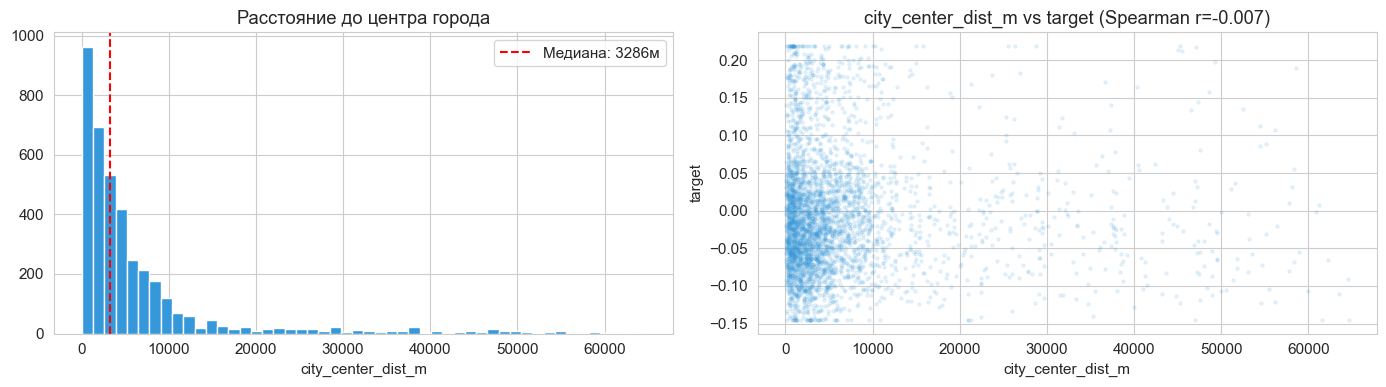

In [4]:
# Распределение расстояния до центра города
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data = df['city_center_dist_m'].dropna()
axes[0].hist(data, bins=50, color='#3498db', edgecolor='white')
axes[0].axvline(data.median(), color='red', linestyle='--', label=f'Медиана: {data.median():.0f}м')
axes[0].set_title('Расстояние до центра города')
axes[0].set_xlabel('city_center_dist_m')
axes[0].legend()

axes[1].scatter(df['city_center_dist_m'], df['target'], alpha=0.1, s=5, color='#3498db')
corr, _ = spearmanr(df['city_center_dist_m'].dropna(), df.loc[df['city_center_dist_m'].notna(), 'target'])
axes[1].set_title(f'city_center_dist_m vs target (Spearman r={corr:.3f})')
axes[1].set_xlabel('city_center_dist_m')
axes[1].set_ylabel('target')

plt.tight_layout()
plt.show()

## 3. Городская статистика (тип, размер, округ)

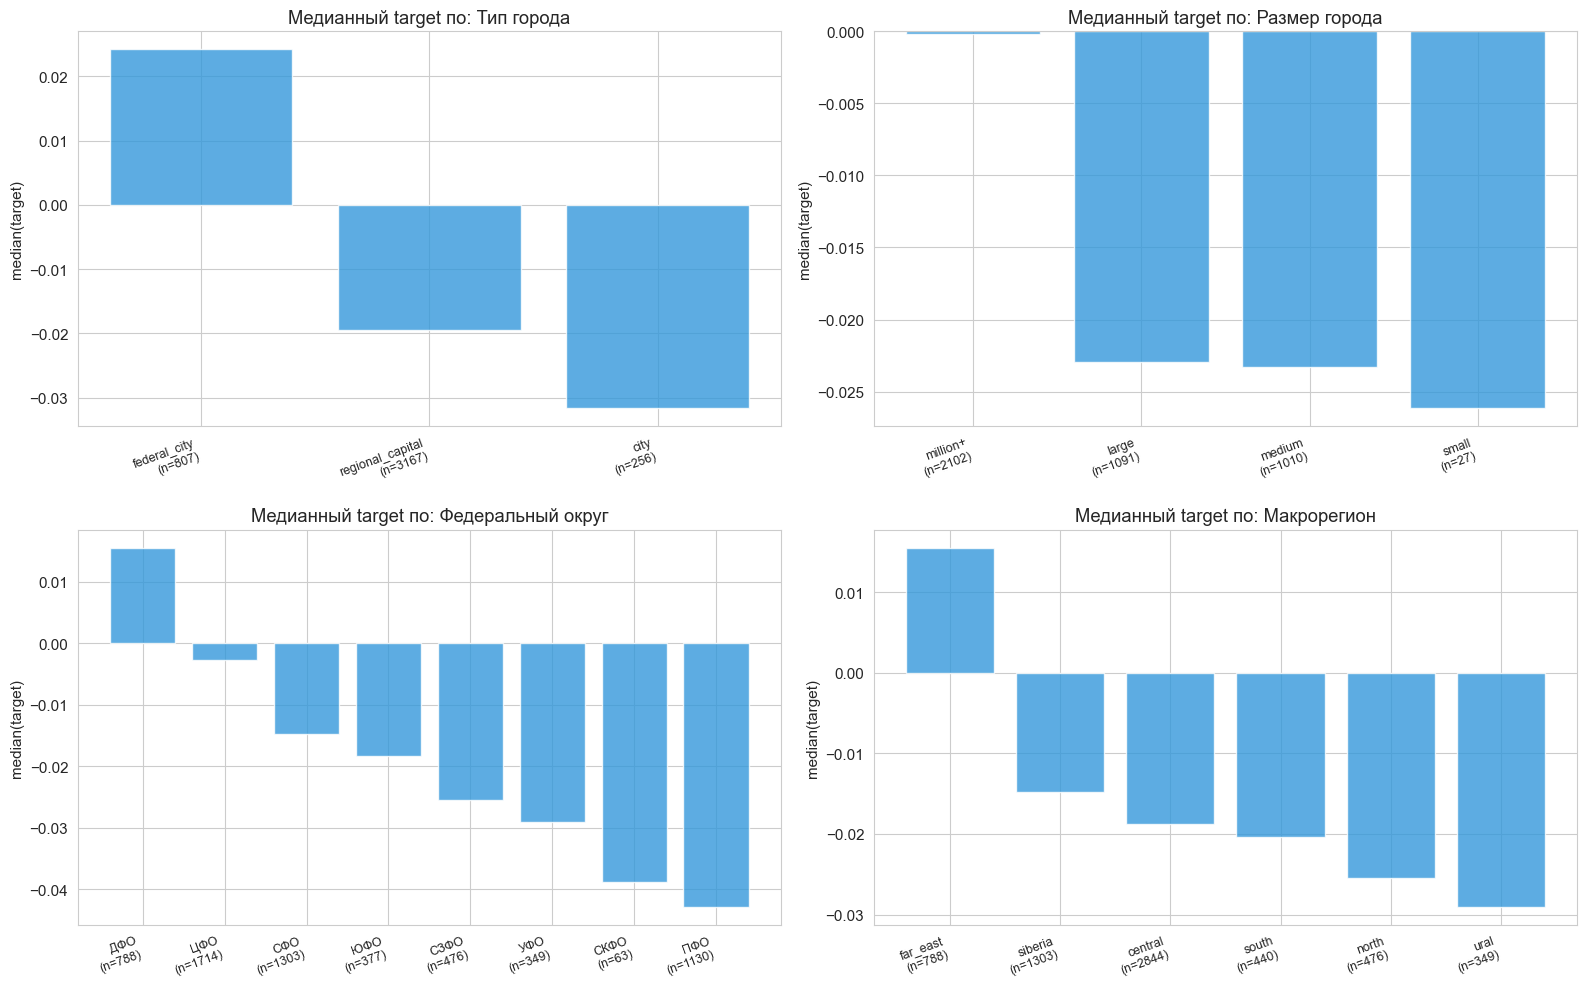

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

cat_cols = [
    ('city_type', 'Тип города'),
    ('city_size_category', 'Размер города'),
    ('federal_district', 'Федеральный округ'),
    ('macro_region', 'Макрорегион'),
]

for ax, (col, title) in zip(axes.flat, cat_cols):
    order = df.groupby(col)['target'].median().sort_values(ascending=False).index
    medians = df.groupby(col)['target'].median().reindex(order)
    counts = df[col].value_counts().reindex(order)
    
    bars = ax.bar(range(len(order)), medians.values, color='#3498db', alpha=0.8)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{c}\n(n={counts[c]})' for c in order], rotation=20, ha='right', fontsize=9)
    ax.set_title(f'Медианный target по: {title}')
    ax.set_ylabel('median(target)')

plt.tight_layout()
plt.show()

In [6]:
# Детальная статистика по категориям
for col, title in cat_cols:
    print(f'\n=== {title} ({col}) ===')
    stats = df.groupby(col)['target'].agg(['count','median','mean','std']).round(4)
    stats.columns = ['n', 'median_target', 'mean_target', 'std_target']
    display(stats.sort_values('median_target', ascending=False))


=== Тип города (city_type) ===


,n,median_target,mean_target,std_target
city_type,,,,
federal_city,807,0.0242,0.0378,0.0841
regional_capital,3167,-0.0194,-0.0027,0.0839
city,256,-0.0317,-0.0188,0.0774



=== Размер города (city_size_category) ===


,n,median_target,mean_target,std_target
city_size_category,,,,
million+,2102,-0.0002,0.0140,0.0858
large,1091,-0.0229,-0.0072,0.0815
medium,1010,-0.0233,-0.0045,0.0854
small,27,-0.0261,0.0053,0.0850



=== Федеральный округ (federal_district) ===


,n,median_target,mean_target,std_target
federal_district,,,,
ДФО,788,0.0155,0.0326,0.0921
ЦФО,1714,-0.0027,0.0080,0.0811
СФО,1303,-0.0148,0.0028,0.0893
ЮФО,377,-0.0183,0.0032,0.0872
СЗФО,476,-0.0255,-0.0039,0.0844
УФО,349,-0.0290,-0.0173,0.0729
СКФО,63,-0.0388,-0.0226,0.0788
ПФО,1130,-0.0428,-0.0265,0.0791



=== Макрорегион (macro_region) ===


,n,median_target,mean_target,std_target
macro_region,,,,
far_east,788,0.0155,0.0326,0.0921
siberia,1303,-0.0148,0.0028,0.0893
central,2844,-0.0188,-0.0057,0.0821
south,440,-0.0204,-0.0005,0.0864
north,476,-0.0255,-0.0039,0.0844
ural,349,-0.0290,-0.0173,0.0729


## 4. Экономические показатели регионов

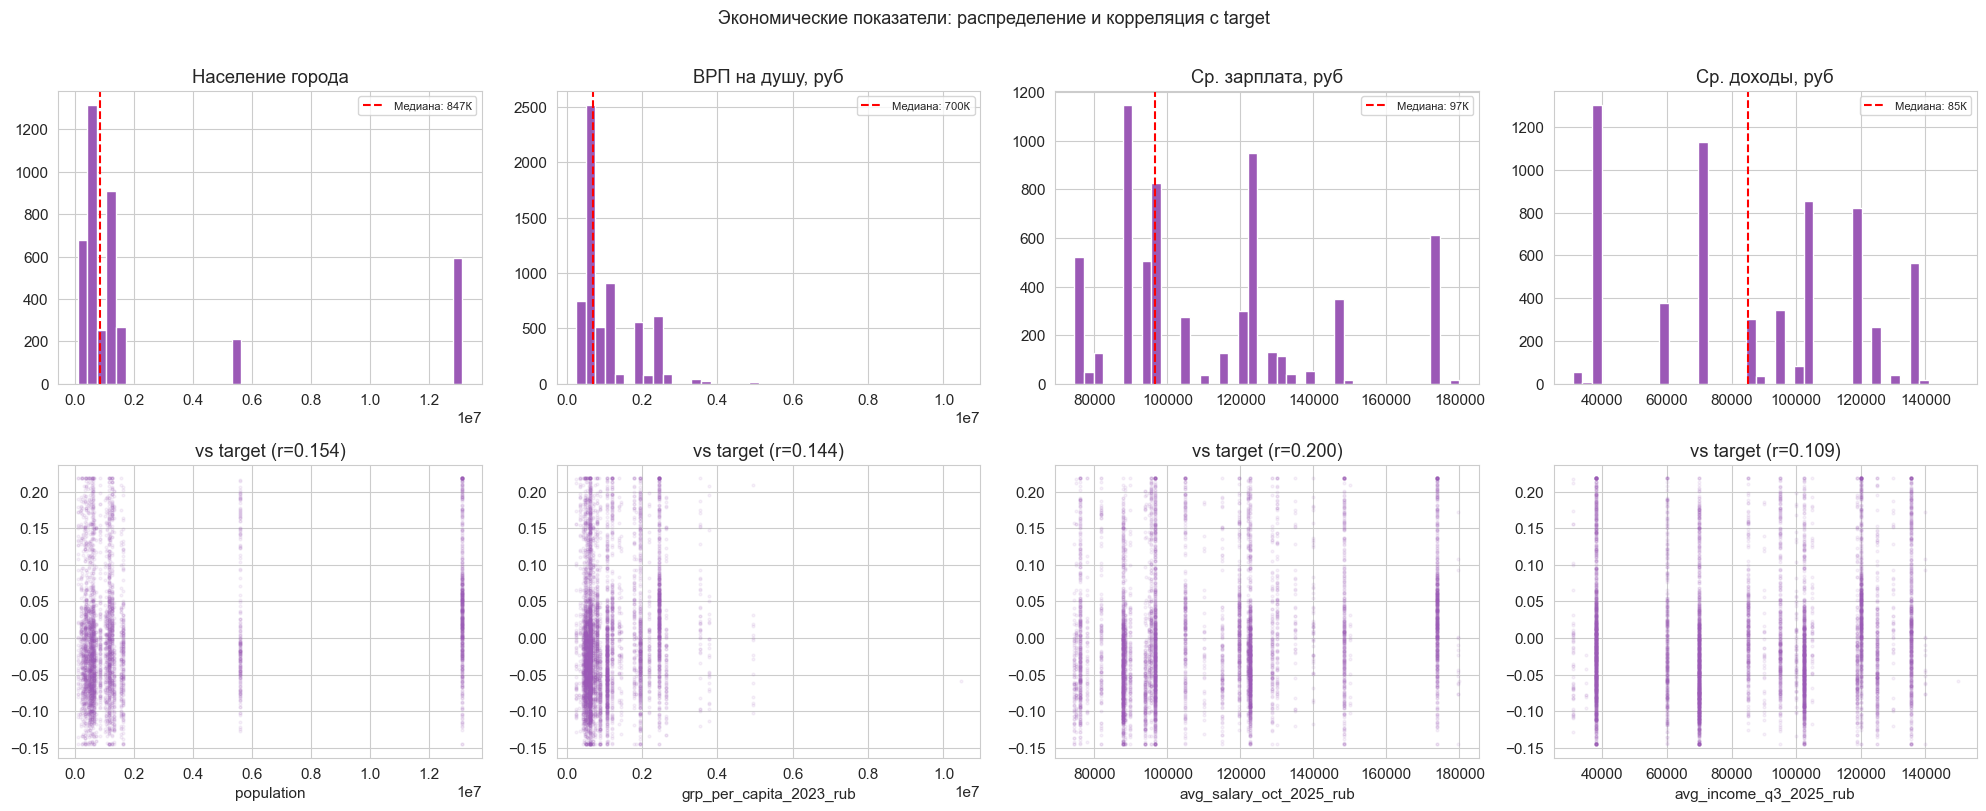

Spearman корреляции с target:
  population                         : r=+0.1545  p=0.0000
  grp_per_capita_2023_rub            : r=+0.1440  p=0.0000
  avg_salary_oct_2025_rub            : r=+0.2000  p=0.0000
  avg_income_q3_2025_rub             : r=+0.1094  p=0.0000


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

econ_cols_info = [
    ('population',              'Население города'),
    ('grp_per_capita_2023_rub', 'ВРП на душу, руб'),
    ('avg_salary_oct_2025_rub', 'Ср. зарплата, руб'),
    ('avg_income_q3_2025_rub',  'Ср. доходы, руб'),
]

for i, (col, title) in enumerate(econ_cols_info):
    data = df[col].dropna()
    
    # Распределение
    axes[0, i].hist(data, bins=40, color='#9b59b6', edgecolor='white')
    axes[0, i].axvline(data.median(), color='red', linestyle='--', label=f'Медиана: {data.median()/1e3:.0f}К')
    axes[0, i].set_title(title)
    axes[0, i].legend(fontsize=8)
    
    # Scatter vs target
    mask = df[col].notna()
    corr, _ = spearmanr(df.loc[mask, col], df.loc[mask, 'target'])
    axes[1, i].scatter(df.loc[mask, col], df.loc[mask, 'target'], alpha=0.08, s=4, color='#9b59b6')
    axes[1, i].set_title(f'vs target (r={corr:.3f})')
    axes[1, i].set_xlabel(col[:25])

plt.suptitle('Экономические показатели: распределение и корреляция с target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Spearman корреляции с target:')
for col, title in econ_cols_info:
    mask = df[col].notna()
    r, p = spearmanr(df.loc[mask, col], df.loc[mask, 'target'])
    print(f'  {col:35s}: r={r:+.4f}  p={p:.4f}')

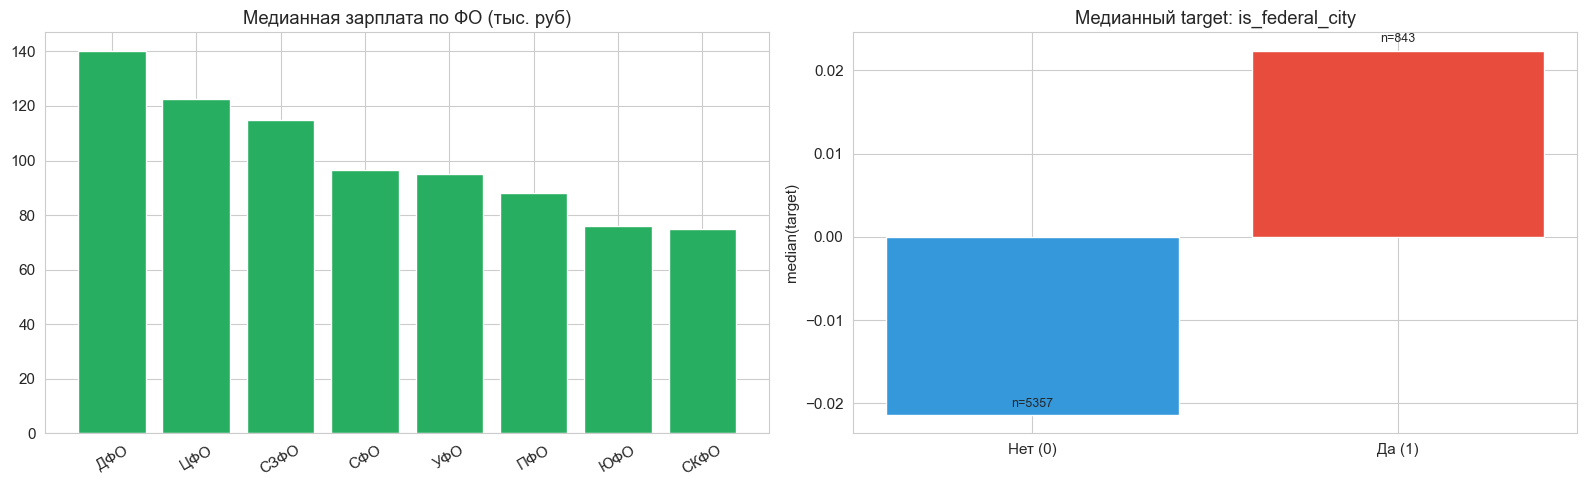

In [8]:
# Зарплата по федеральным округам
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

salary_by_fd = df.groupby('federal_district')['avg_salary_oct_2025_rub'].median().sort_values(ascending=False)
axes[0].bar(salary_by_fd.index, salary_by_fd.values / 1000, color='#27ae60')
axes[0].set_title('Медианная зарплата по ФО (тыс. руб)')
axes[0].tick_params(axis='x', rotation=30)

# Флаги федерального значения
for ax, col, title in [
    (axes[1], 'is_federal_city', 'is_federal_city'),
]:
    stats = df.groupby(col)['target'].agg(['median','count'])
    ax.bar(['Нет (0)', 'Да (1)'], stats['median'], color=['#3498db','#e74c3c'])
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.text(i, row['median'] + 0.001, f'n={int(row["count"])}', ha='center', fontsize=9)
    ax.set_title(f'Медианный target: {title}')
    ax.set_ylabel('median(target)')

plt.tight_layout()
plt.show()

## 5. Новые POI: дистанционные фичи

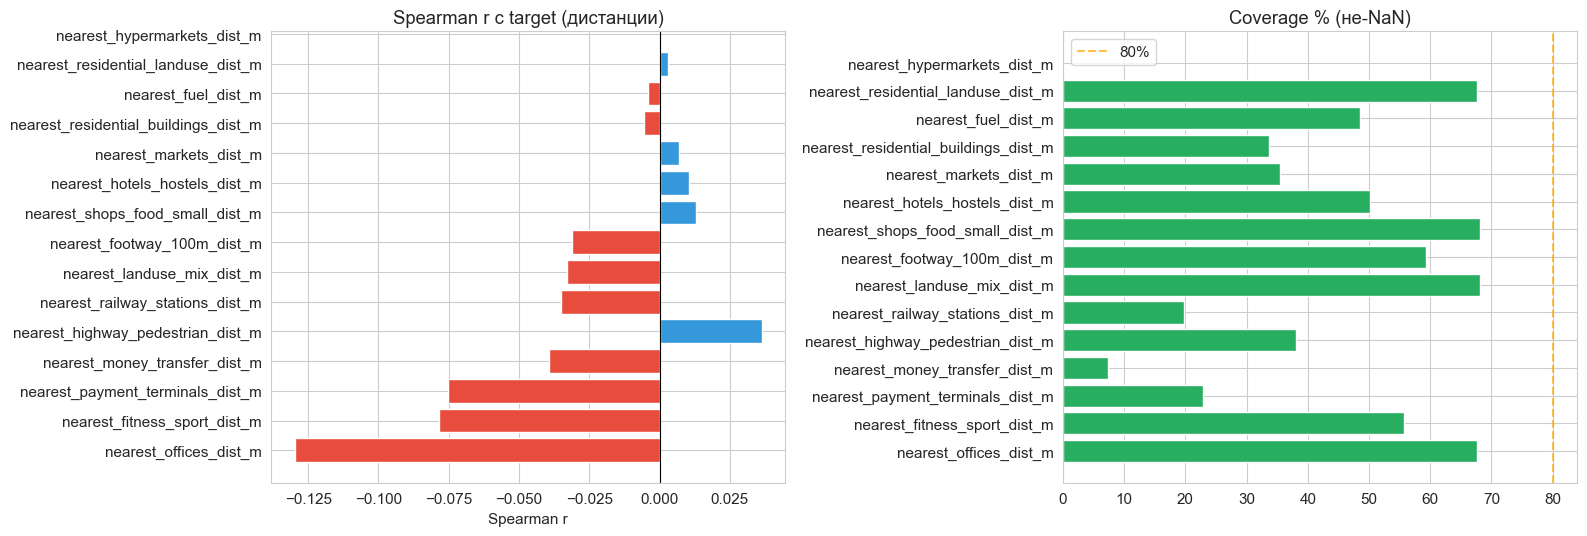

,feature,coverage_%,spearman_r,p_value
0,nearest_offices_dist_m,67.700000,-0.129800,0.000000
6,nearest_fitness_sport_dist_m,55.800000,-0.078500,0.000000
1,nearest_payment_terminals_dist_m,22.800000,-0.075300,0.004600
2,nearest_money_transfer_dist_m,7.300000,-0.039500,0.403000
12,nearest_highway_pedestrian_dist_m,38.100000,0.036400,0.077100
8,nearest_railway_stations_dist_m,19.800000,-0.034900,0.221900
14,nearest_landuse_mix_dist_m,68.200000,-0.033100,0.031500
13,nearest_footway_100m_dist_m,59.300000,-0.031200,0.058500
3,nearest_shops_food_small_dist_m,68.100000,0.013000,0.399800
7,nearest_hotels_hostels_dist_m,50.100000,0.010500,0.558400


In [9]:
# Coverage (% не-NaN) и корреляция с target для всех дистанций
dist_stats = []
for col in POI_DIST_COLS:
    mask = df[col].notna()
    coverage = mask.mean() * 100
    if mask.sum() > 100:
        r, p = spearmanr(df.loc[mask, col], df.loc[mask, 'target'])
    else:
        r, p = np.nan, np.nan
    dist_stats.append({'feature': col, 'coverage_%': round(coverage, 1), 'spearman_r': round(r, 4) if not np.isnan(r) else np.nan, 'p_value': round(p, 4) if not np.isnan(p) else np.nan})

dist_df = pd.DataFrame(dist_stats).sort_values('spearman_r', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(dist_df)*0.3 + 1)))

colors_r = ['#e74c3c' if r < 0 else '#3498db' for r in dist_df['spearman_r']]
axes[0].barh(dist_df['feature'], dist_df['spearman_r'], color=colors_r)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Spearman r с target (дистанции)')
axes[0].set_xlabel('Spearman r')

axes[1].barh(dist_df['feature'], dist_df['coverage_%'], color='#27ae60')
axes[1].axvline(80, color='orange', linestyle='--', alpha=0.7, label='80%')
axes[1].set_title('Coverage % (не-NaN)')
axes[1].legend()

plt.tight_layout()
plt.show()

display(dist_df.style.background_gradient(cmap='RdBu_r', subset=['spearman_r'])
              .background_gradient(cmap='Greens', subset=['coverage_%']))

## 6. Новые POI: счётчики в радиусе 300м

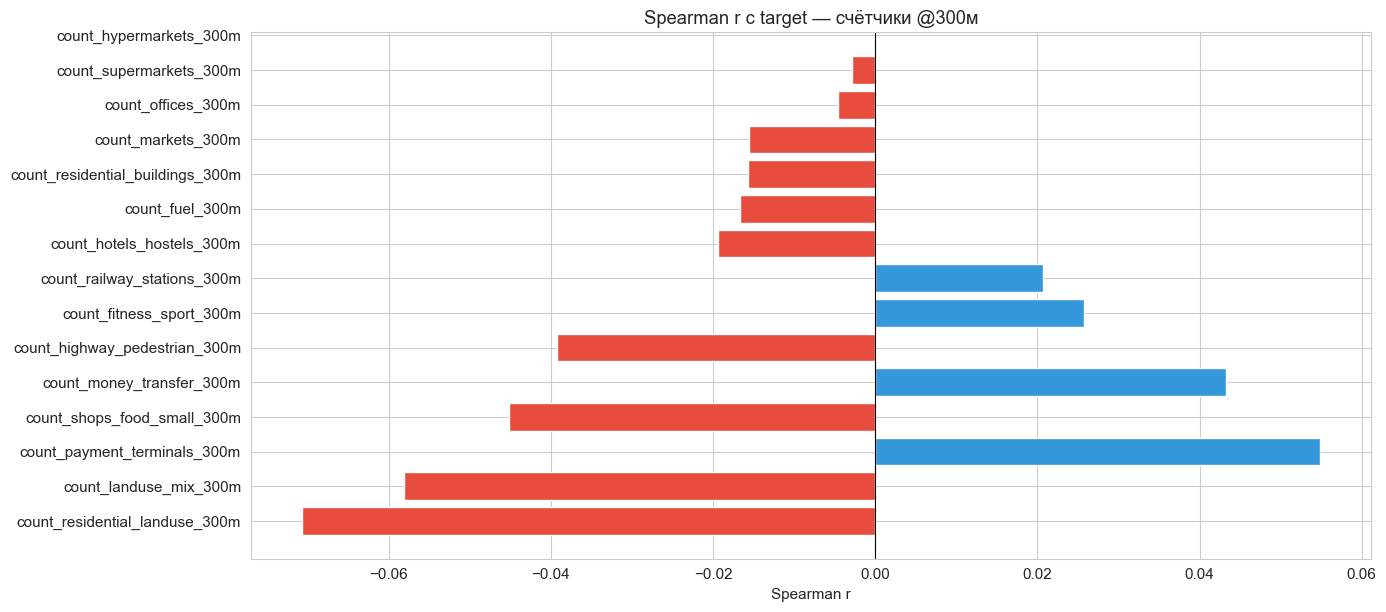

,feature,coverage_%,spearman_r,median,mean
11,count_residential_landuse_300m,100.000000,-0.070700,0.000000,1.452581
14,count_landuse_mix_300m,100.000000,-0.058100,1.000000,2.297742
2,count_payment_terminals_300m,100.000000,0.054900,0.000000,0.152419
4,count_shops_food_small_300m,100.000000,-0.045200,0.000000,1.456774
3,count_money_transfer_300m,100.000000,0.043200,0.000000,0.027097
13,count_highway_pedestrian_300m,100.000000,-0.039200,0.000000,0.360484
7,count_fitness_sport_300m,100.000000,0.025800,0.000000,0.326935
9,count_railway_stations_300m,100.000000,0.020700,0.000000,0.083871
8,count_hotels_hostels_300m,100.000000,-0.019400,0.000000,0.459194
12,count_fuel_300m,100.000000,-0.016700,0.000000,0.118710


In [10]:
# Корреляция счётчиков @300м с target
count_stats = []
for col in POI_COUNT_300:
    mask = df[col].notna()
    coverage = mask.mean() * 100
    if mask.sum() > 100:
        r, p = spearmanr(df.loc[mask, col], df.loc[mask, 'target'])
    else:
        r, p = np.nan, np.nan
    count_stats.append({'feature': col, 'coverage_%': round(coverage, 1),
                        'spearman_r': round(r, 4) if not np.isnan(r) else np.nan,
                        'median': df[col].median(), 'mean': df[col].mean()})

count_df = pd.DataFrame(count_stats).sort_values('spearman_r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, max(4, len(count_df)*0.35 + 1)))
colors_r = ['#e74c3c' if r < 0 else '#3498db' for r in count_df['spearman_r']]
ax.barh(count_df['feature'], count_df['spearman_r'], color=colors_r)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman r с target — счётчики @300м')
ax.set_xlabel('Spearman r')
plt.tight_layout()
plt.show()

display(count_df.style.background_gradient(cmap='RdBu_r', subset=['spearman_r']))

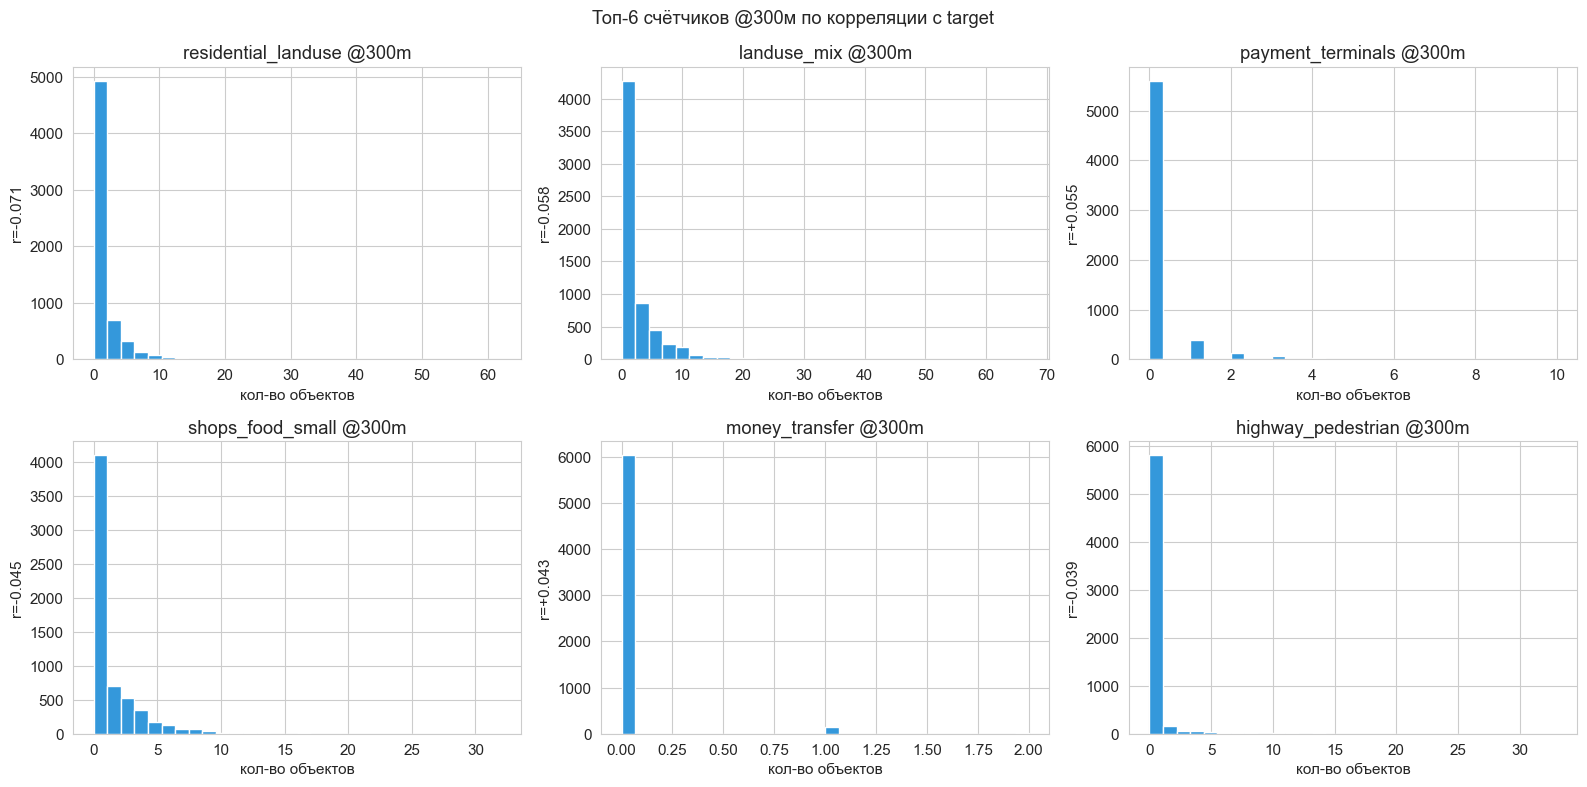

In [11]:
# Распределения топ-счётчиков (по |r|)
top_count_cols = count_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, top_count_cols):
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#3498db', edgecolor='white')
    ax.set_title(col.replace('count_', '').replace('_300m', ' @300m'))
    ax.set_xlabel('кол-во объектов')
    r = count_df.loc[count_df['feature'] == col, 'spearman_r'].values[0]
    ax.set_ylabel(f'r={r:+.3f}')

plt.suptitle('Топ-6 счётчиков @300м по корреляции с target')
plt.tight_layout()
plt.show()

## 7. Сравнение счётчиков по радиусам (100 / 300 / 500 / 1000м)

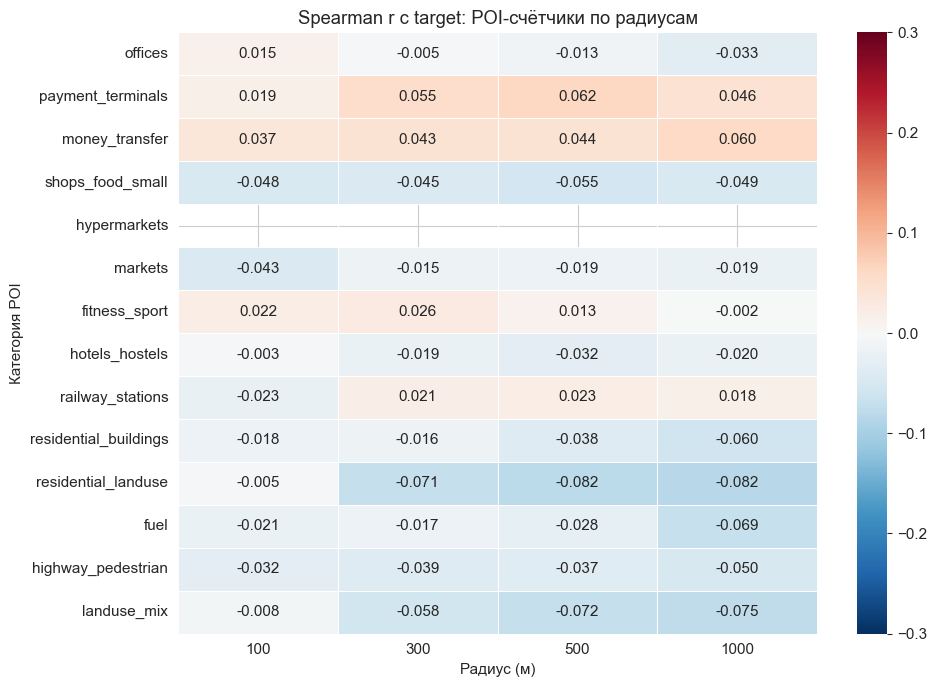

In [12]:
# POI-категории с данными на всех радиусах
categories = [
    'offices', 'payment_terminals', 'money_transfer', 'shops_food_small',
    'hypermarkets', 'markets', 'fitness_sport', 'hotels_hostels',
    'railway_stations', 'residential_buildings', 'residential_landuse',
    'fuel', 'highway_pedestrian', 'landuse_mix'
]
radii = [100, 300, 500, 1000]

# Spearman r для каждой категории × радиус
corr_matrix = pd.DataFrame(index=categories, columns=radii, dtype=float)

for cat in categories:
    for r in radii:
        col = f'count_{cat}_{r}m'
        if col in df.columns:
            mask = df[col].notna()
            if mask.sum() > 50:
                rho, _ = spearmanr(df.loc[mask, col], df.loc[mask, 'target'])
                corr_matrix.loc[cat, r] = round(rho, 4)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, vmin=-0.3, vmax=0.3)
ax.set_title('Spearman r с target: POI-счётчики по радиусам')
ax.set_xlabel('Радиус (м)')
ax.set_ylabel('Категория POI')
plt.tight_layout()
plt.show()

## 8. Топ новых фичей по корреляции с target

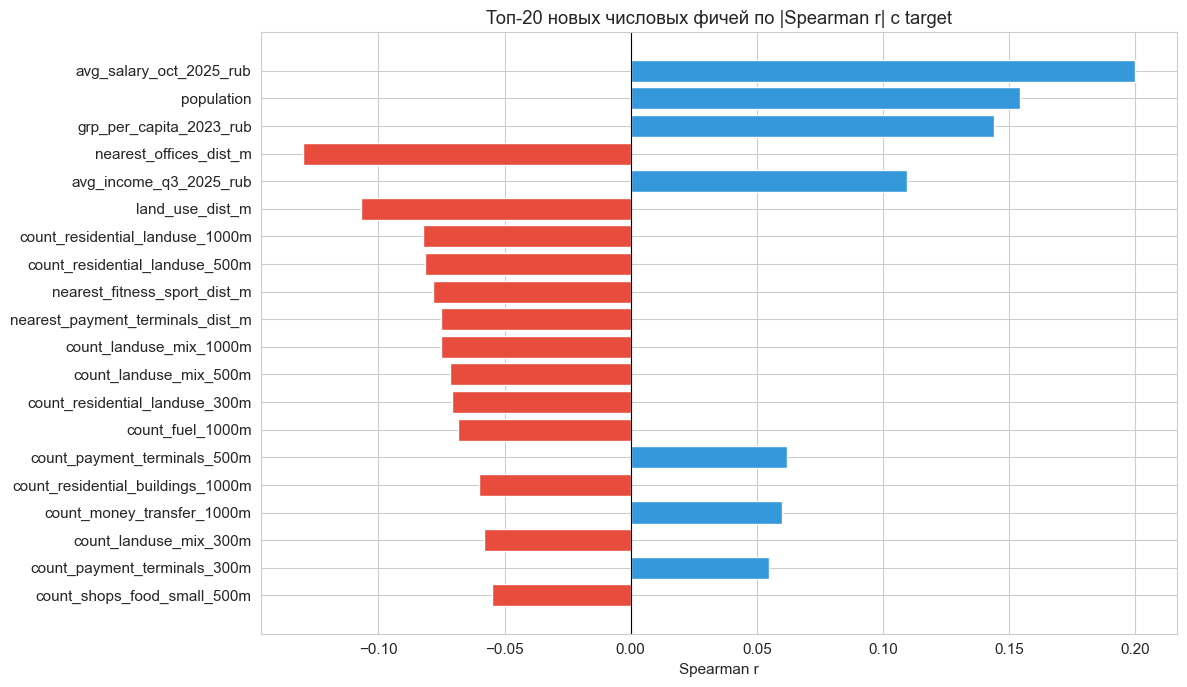

Топ-20 новых фичей:


,feature,spearman_r,p_value,coverage_%
77,avg_salary_oct_2025_rub,0.199995,0.000000,100.000000
75,population,0.154451,0.000000,68.225806
76,grp_per_capita_2023_rub,0.144007,0.000000,100.000000
1,nearest_offices_dist_m,-0.129826,0.000000,67.741935
78,avg_income_q3_2025_rub,0.109418,0.000000,100.000000
72,land_use_dist_m,-0.106815,0.000000,95.258065
53,count_residential_landuse_1000m,-0.082201,0.000000,100.000000
52,count_residential_landuse_500m,-0.081532,0.000000,100.000000
30,nearest_fitness_sport_dist_m,-0.078532,0.000004,55.822581
10,nearest_payment_terminals_dist_m,-0.075335,0.004606,22.790323


In [13]:
# Все новые числовые фичи vs target
num_new_cols = df[NEW_COLS].select_dtypes(include=[np.number]).columns.tolist()

all_corr = []
for col in num_new_cols:
    mask = df[col].notna()
    if mask.sum() < 50:
        continue
    r, p = spearmanr(df.loc[mask, col], df.loc[mask, 'target'])
    all_corr.append({'feature': col, 'spearman_r': r, 'p_value': p,
                     'coverage_%': mask.mean()*100, 'abs_r': abs(r)})

corr_all = pd.DataFrame(all_corr).sort_values('abs_r', ascending=False)

# Топ-20
top20 = corr_all.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if r < 0 else '#3498db' for r in top20['spearman_r']]
ax.barh(top20['feature'][::-1], top20['spearman_r'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Топ-20 новых числовых фичей по |Spearman r| с target')
ax.set_xlabel('Spearman r')
plt.tight_layout()
plt.show()

print('Топ-20 новых фичей:')
display(corr_all.head(20)[['feature','spearman_r','p_value','coverage_%']]
        .style.background_gradient(cmap='RdBu_r', subset=['spearman_r']))

## 9. Новые категориальные фичи vs target (boxplot)

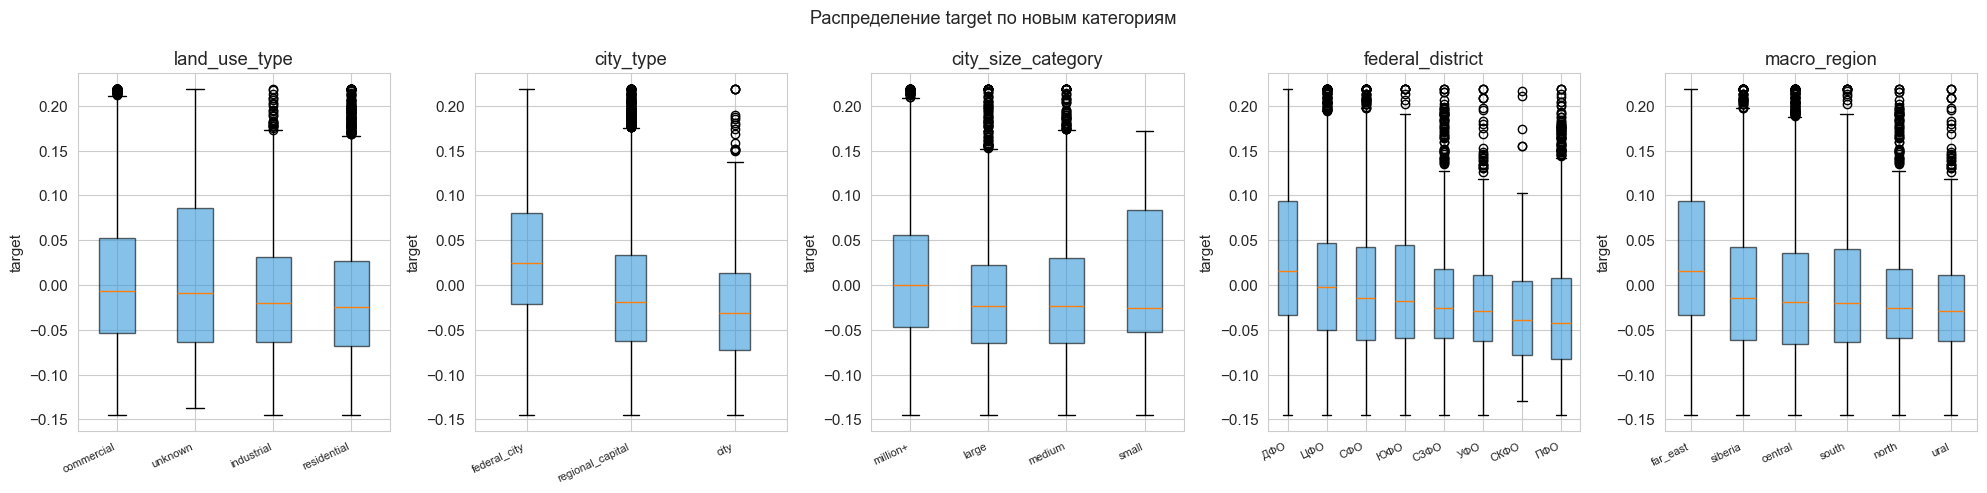

In [14]:
cat_new = ['land_use_type'] + ECON_CAT_COLS

fig, axes = plt.subplots(1, len(cat_new), figsize=(20, 5))

for ax, col in zip(axes, cat_new):
    order = df.groupby(col)['target'].median().sort_values(ascending=False).index
    data_grouped = [df.loc[df[col] == cat, 'target'].dropna().values for cat in order]
    bp = ax.boxplot(data_grouped, patch_artist=True, notch=False)
    for patch in bp['boxes']:
        patch.set_facecolor('#3498db')
        patch.set_alpha(0.6)
    ax.set_xticklabels(order, rotation=25, ha='right', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('target')

plt.suptitle('Распределение target по новым категориям', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Корреляция новых фичей между собой (heatmap)

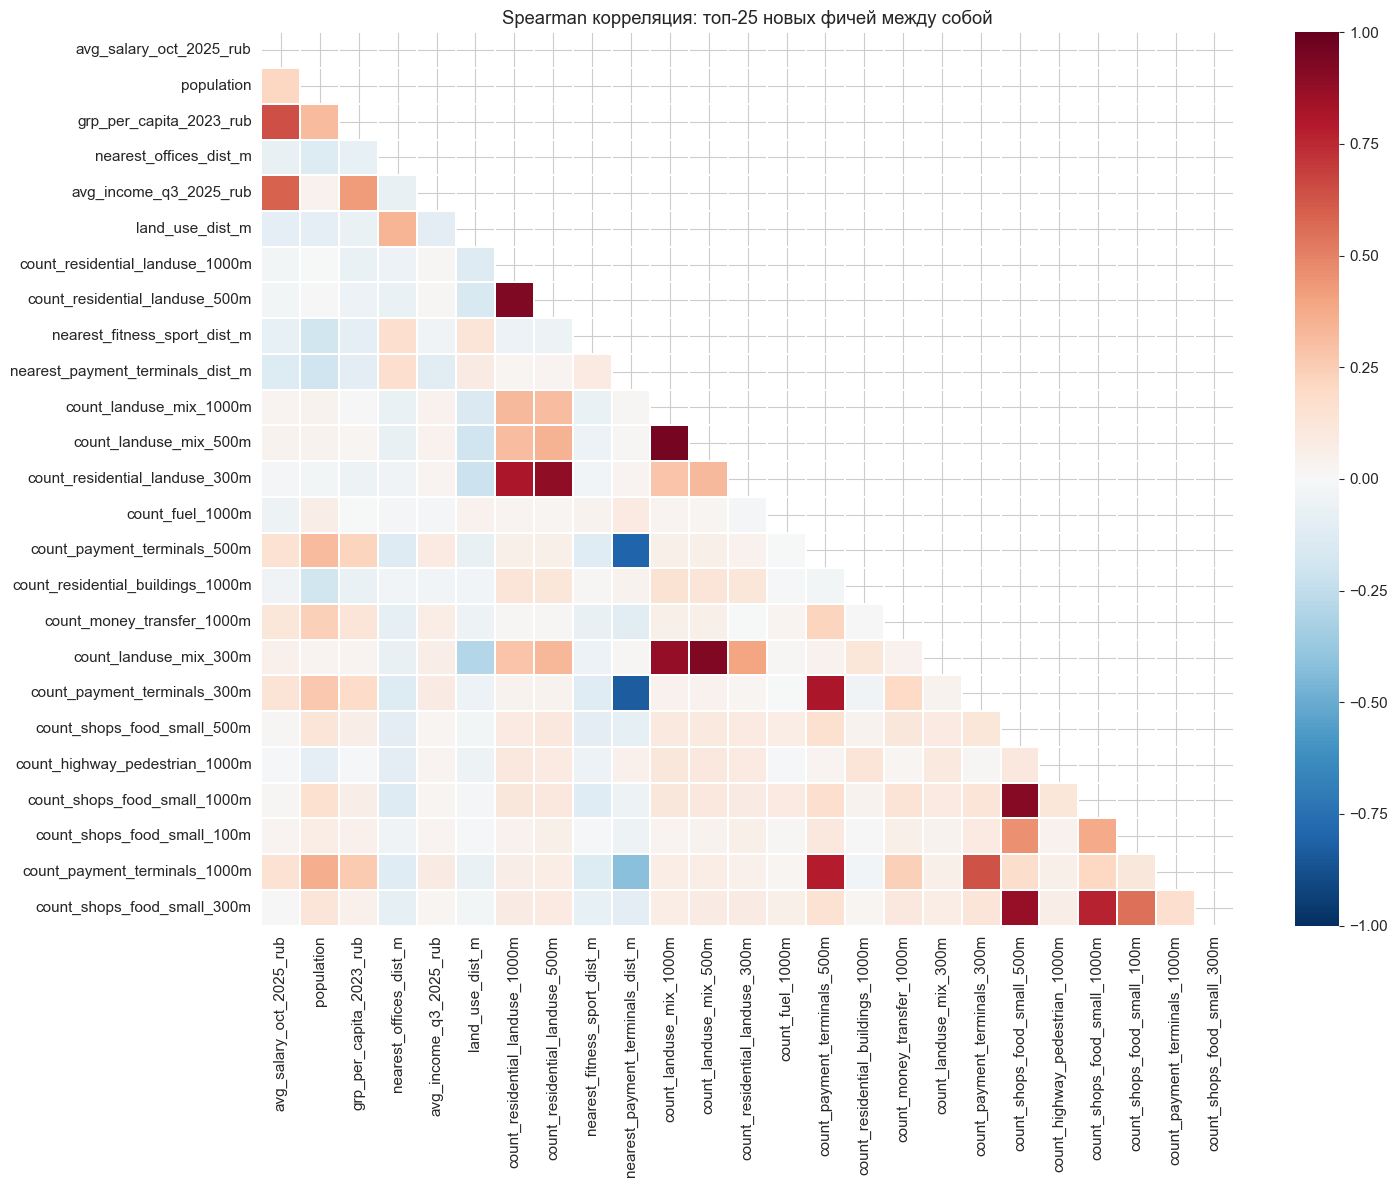

In [15]:
# Топ-25 новых числовых фичей по корреляции с target для heatmap
top25_cols = corr_all.head(25)['feature'].tolist()

corr_matrix_top = df[top25_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(15, 12))
mask_tri = np.triu(np.ones_like(corr_matrix_top, dtype=bool))
sns.heatmap(corr_matrix_top, mask=mask_tri, annot=False, cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.3, vmin=-1, vmax=1)
ax.set_title('Spearman корреляция: топ-25 новых фичей между собой')
plt.tight_layout()
plt.show()

## 11. Профиль банкомата по типу земли и городу

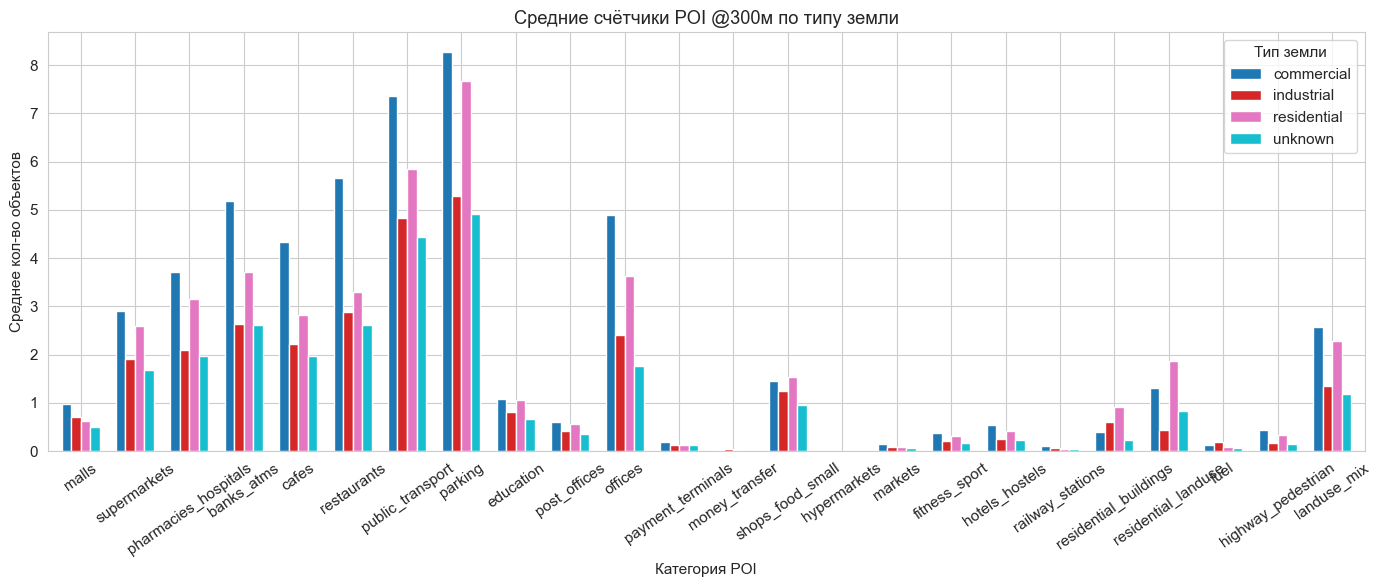

In [16]:
# Средние POI-счётчики @300м по типу земли
count_300_cols = [c for c in df.columns if 'count_' in c and '_300m' in c]
profile = df.groupby('land_use_type')[count_300_cols].mean().T
profile.index = [c.replace('count_','').replace('_300m','') for c in profile.index]

fig, ax = plt.subplots(figsize=(14, 6))
profile.plot(kind='bar', ax=ax, colormap='tab10', width=0.7)
ax.set_title('Средние счётчики POI @300м по типу земли')
ax.set_xlabel('Категория POI')
ax.set_ylabel('Среднее кол-во объектов')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Тип земли')
plt.tight_layout()
plt.show()

In [17]:
# Сводная таблица: средние значения ключевых новых фичей по city_size_category
key_new = [
    'city_center_dist_m', 'count_residential_buildings_300m',
    'count_shops_food_small_300m', 'count_offices_300m',
    'count_fitness_sport_300m', 'count_markets_300m',
    'grp_per_capita_2023_rub', 'avg_salary_oct_2025_rub'
]
order_size = ['million+', 'large', 'medium', 'small']
summary = df.groupby('city_size_category')[key_new].median().reindex(
    [c for c in order_size if c in df['city_size_category'].unique()]
).round(1)
summary.columns = [c.replace('count_','').replace('_300m','').replace('_2023_rub','').replace('_oct_2025_rub','') for c in summary.columns]

print('Медианные значения ключевых фичей по размеру города:')
display(summary)

Медианные значения ключевых фичей по размеру города:


,city_center_dist_m,residential_buildings,shops_food_small,offices,fitness_sport,markets,grp_per_capita,avg_salary
city_size_category,,,,,,,,
million+,4566.9,0.0,1.0,2.0,0.0,0.0,900000.0,104869.1
large,2694.0,0.0,0.0,1.0,0.0,0.0,610000.0,95553.5
medium,2006.2,0.0,0.0,1.0,0.0,0.0,1080887.5,122661.0
small,849.0,0.0,1.0,2.0,0.0,0.0,1850000.0,179674.4


## 12. Итоговый рейтинг новых фичей для ML

In [18]:
# Итоговая таблица: все новые числовые фичи с метриками
final_report = corr_all.copy()
final_report['useful'] = (final_report['coverage_%'] > 50) & (final_report['p_value'] < 0.05)
final_report['priority'] = pd.cut(final_report['abs_r'],
                                   bins=[0, 0.05, 0.10, 0.15, 1.0],
                                   labels=['low', 'medium', 'high', 'very_high'])

print(f"Всего новых числовых фичей: {len(final_report)}")
print(f"Значимых (p<0.05 и coverage>50%): {final_report['useful'].sum()}")
print(f"Приоритет high+: {(final_report['priority'].isin(['high','very_high'])).sum()}")
print()
print('Распределение по приоритету:')
print(final_report['priority'].value_counts())

display(
    final_report.sort_values('abs_r', ascending=False)
    [['feature','spearman_r','p_value','coverage_%','priority','useful']]
    .style.background_gradient(cmap='RdBu_r', subset=['spearman_r'])
          .background_gradient(cmap='Greens', subset=['coverage_%'])
          .map(lambda v: 'background-color: #d5f5e3' if v else '', subset=['useful'])
)

Всего новых числовых фичей: 79
Значимых (p<0.05 и coverage>50%): 38
Приоритет high+: 6

Распределение по приоритету:
priority
low          55
medium       14
high          4
very_high     2
Name: count, dtype: int64


,feature,spearman_r,p_value,coverage_%,priority,useful
77,avg_salary_oct_2025_rub,0.199995,0.000000,100.000000,very_high,True
75,population,0.154451,0.000000,68.225806,very_high,True
76,grp_per_capita_2023_rub,0.144007,0.000000,100.000000,high,True
1,nearest_offices_dist_m,-0.129826,0.000000,67.741935,high,True
78,avg_income_q3_2025_rub,0.109418,0.000000,100.000000,high,True
72,land_use_dist_m,-0.106815,0.000000,95.258065,high,True
53,count_residential_landuse_1000m,-0.082201,0.000000,100.000000,medium,True
52,count_residential_landuse_500m,-0.081532,0.000000,100.000000,medium,True
30,nearest_fitness_sport_dist_m,-0.078532,0.000004,55.822581,medium,True
10,nearest_payment_terminals_dist_m,-0.075335,0.004606,22.790323,medium,False


In [19]:
# Финальный список рекомендованных новых фичей для добавления в модель
recommended = final_report[
    (final_report['useful']) & 
    (final_report['priority'].isin(['high', 'very_high']))
]['feature'].tolist()

print(f'Рекомендовано к добавлению в LOCATION_FEATURES: {len(recommended)} фичей')
print()
for f in recommended:
    r_val = final_report.loc[final_report['feature']==f, 'spearman_r'].values[0]
    cov = final_report.loc[final_report['feature']==f, 'coverage_%'].values[0]
    print(f'  "{f}",  # r={r_val:+.4f}, coverage={cov:.0f}%')

print()
print('Новые категориальные фичи для добавления в CATEGORICAL_FEATURES:')
new_cat_for_model = ['land_use_type', 'city_size_category']
for c in new_cat_for_model:
    print(f'  "{c}"')

Рекомендовано к добавлению в LOCATION_FEATURES: 6 фичей

  "avg_salary_oct_2025_rub",  # r=+0.2000, coverage=100%
  "population",  # r=+0.1545, coverage=68%
  "grp_per_capita_2023_rub",  # r=+0.1440, coverage=100%
  "nearest_offices_dist_m",  # r=-0.1298, coverage=68%
  "avg_income_q3_2025_rub",  # r=+0.1094, coverage=100%
  "land_use_dist_m",  # r=-0.1068, coverage=95%

Новые категориальные фичи для добавления в CATEGORICAL_FEATURES:
  "land_use_type"
  "city_size_category"


# Дополнительный анализ: target, старые признаки, мультиколлинеарность, MI

Разделы 1–12 разбирают только **новые** фичи. Ниже — то, чего не хватало: целевая переменная, **старые признаки** (POI v1, бинарные функции банкомата, банк-владелец, плотность), систематическая редундантность по всему набору и нелинейная зависимость (mutual information).

## 13. Целевая переменная `target`

min=-0.1450  max=0.2186  mean=0.0008  median=-0.0155  std=0.0859
skew=0.807  kurtosis=0.024  выбросов(IQR)=3.7%


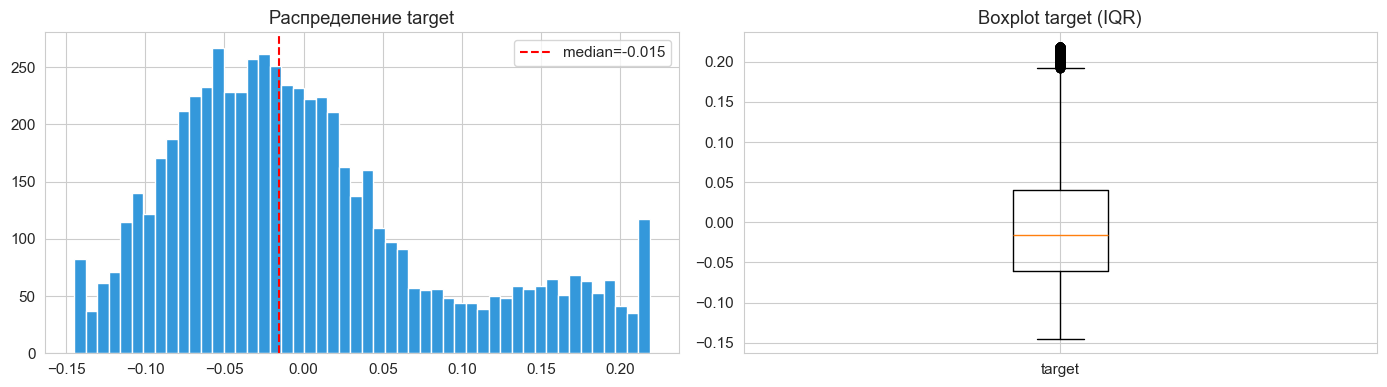

In [20]:
from scipy.stats import skew, kurtosis

t = df[TARGET].dropna()
q1, q3 = t.quantile(.25), t.quantile(.75); iqr = q3 - q1
out = ((t < q1 - 1.5*iqr) | (t > q3 + 1.5*iqr)).mean() * 100
print(f'min={t.min():.4f}  max={t.max():.4f}  mean={t.mean():.4f}  '
      f'median={t.median():.4f}  std={t.std():.4f}')
print(f'skew={skew(t):.3f}  kurtosis={kurtosis(t):.3f}  выбросов(IQR)={out:.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(t, bins=50, color='#3498db', edgecolor='white')
ax[0].axvline(t.median(), color='red', ls='--', label=f'median={t.median():.3f}')
ax[0].set_title('Распределение target'); ax[0].legend()
ax[1].boxplot(t, showfliers=True); ax[1].set_xticks([1]); ax[1].set_xticklabels(['target'])
ax[1].set_title('Boxplot target (IQR)')
plt.tight_layout(); plt.show()

`target` распределён **почти симметрично** вокруг нуля (медиана ≈ 0), без тяжёлых хвостов и с низкой долей выбросов — удобно для регрессии, метрики RMSE/MAE/R² адекватны.

## 14. Старые признаки (POI v1 + плотность) vs target

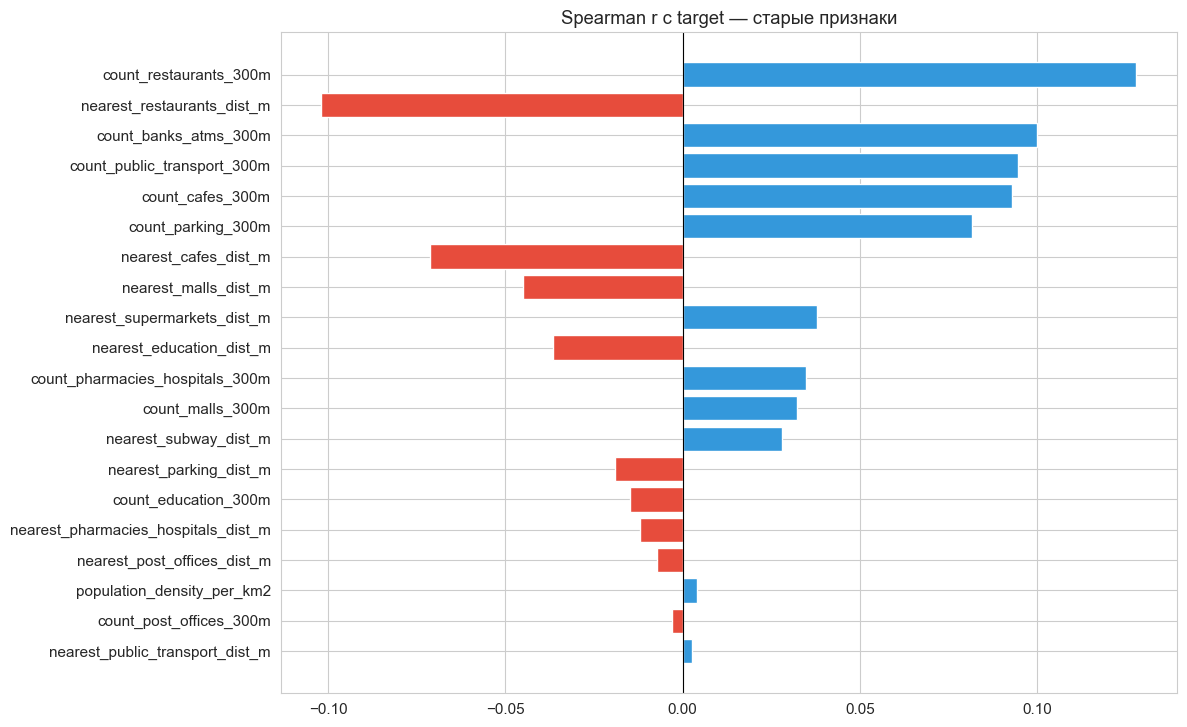

,feature,coverage_%,spearman_r
14,count_restaurants_300m,100.000000,0.128000
4,nearest_restaurants_dist_m,91.100000,-0.101900
12,count_banks_atms_300m,100.000000,0.100100
15,count_public_transport_300m,100.000000,0.094700
13,count_cafes_300m,100.000000,0.092900
16,count_parking_300m,100.000000,0.081600
3,nearest_cafes_dist_m,92.200000,-0.071200
0,nearest_malls_dist_m,76.800000,-0.045100
1,nearest_supermarkets_dist_m,95.700000,0.037900
7,nearest_education_dist_m,74.600000,-0.036500


In [21]:
# Старые числовые признаки из OLD_COLS
OLD_DIST = [c for c in OLD_COLS if c.startswith('nearest_') and c.endswith('_dist_m')]
OLD_COUNT = [c for c in OLD_COLS if c.startswith('count_')]
OLD_NUM = [c for c in OLD_DIST + OLD_COUNT + ['population_density_per_km2'] if c in df.columns]

def rank_sp(cols):
    rows = []
    for c in cols:
        m = df[c].notna(); cov = m.mean() * 100
        r = spearmanr(df.loc[m, c], df.loc[m, TARGET])[0] if m.sum() > 100 else np.nan
        rows.append({'feature': c, 'coverage_%': round(cov, 1),
                     'spearman_r': round(r, 4) if r == r else np.nan})
    return pd.DataFrame(rows).sort_values('spearman_r', key=lambda s: s.abs(), ascending=False)

old_df = rank_sp(OLD_NUM)
fig, ax = plt.subplots(figsize=(12, max(4, len(old_df) * 0.32 + 1)))
colors = ['#e74c3c' if r < 0 else '#3498db' for r in old_df['spearman_r']]
ax.barh(old_df['feature'][::-1], old_df['spearman_r'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=.8); ax.set_title('Spearman r с target — старые признаки')
plt.tight_layout(); plt.show()
display(old_df.style.background_gradient(cmap='RdBu_r', subset=['spearman_r']))

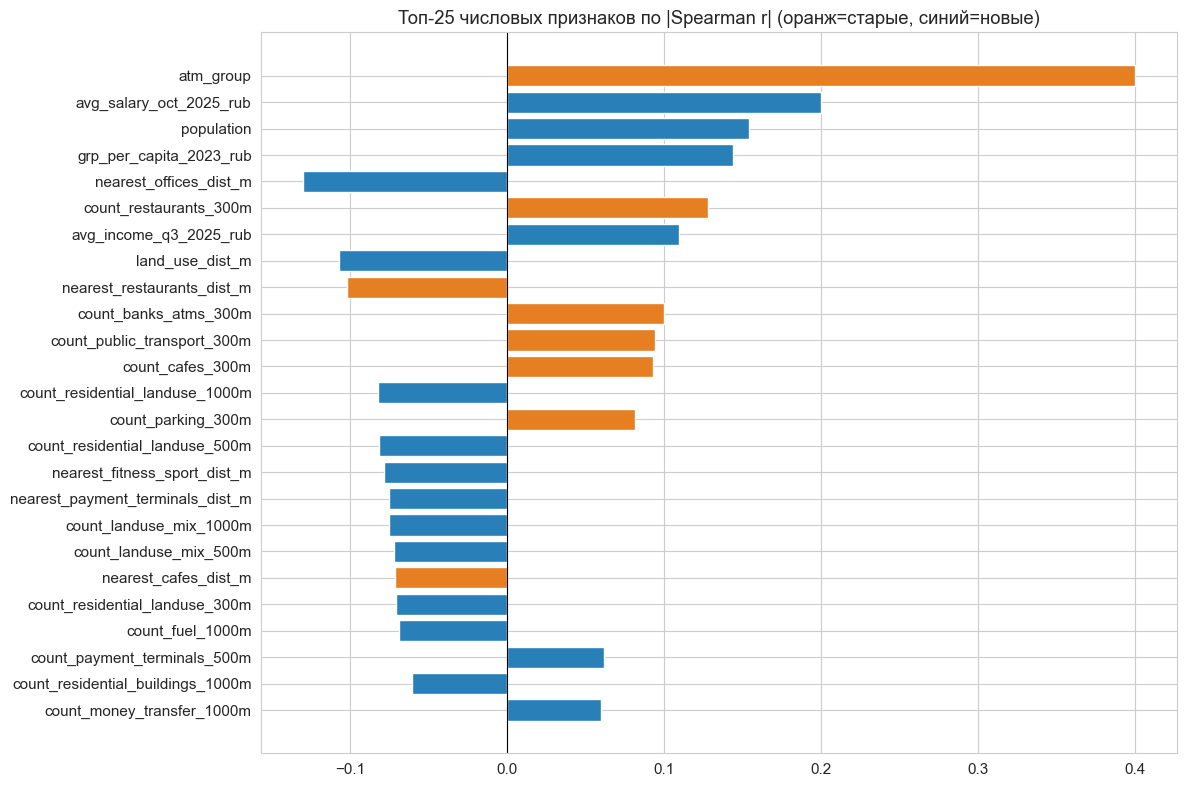

Старых в топ-25: 8 | Новых: 17


In [22]:
# Объединённый топ: старые + новые числовые vs target (что сильнее)
num_all = [c for c in df.select_dtypes(include=[np.number]).columns
           if c not in ['id', 'geo_lon', 'geo_lat', 'target']]
rows = []
for c in num_all:
    m = df[c].notna()
    if m.sum() < 100: continue
    r = spearmanr(df.loc[m, c], df.loc[m, TARGET])[0]
    rows.append({'feature': c, 'spearman_r': r, 'abs': abs(r),
                 'group': 'новая' if c in NEW_COLS else 'старая'})
comb = pd.DataFrame(rows).sort_values('abs', ascending=False)
top = comb.head(25)
fig, ax = plt.subplots(figsize=(12, 8))
cmap = {'старая': '#e67e22', 'новая': '#2980b9'}
ax.barh(top['feature'][::-1], top['spearman_r'][::-1],
        color=[cmap[g] for g in top['group'][::-1]])
ax.axvline(0, color='black', lw=.8)
ax.set_title('Топ-25 числовых признаков по |Spearman r| (оранж=старые, синий=новые)')
plt.tight_layout(); plt.show()
print('Старых в топ-25:', (top['group'] == 'старая').sum(),
      '| Новых:', (top['group'] == 'новая').sum())

Старые POI-признаки по линейной/монотонной связи с `target` так же **слабы**, как новые (|r| мал). Сильнее прочих — `population_density_per_km2` и пешеходно-транспортная/пищевая инфраструктура. В объединённом топе старые и новые перемешаны — однозначного победителя по корреляции нет.

## 15. Бинарные признаки банкомата vs target

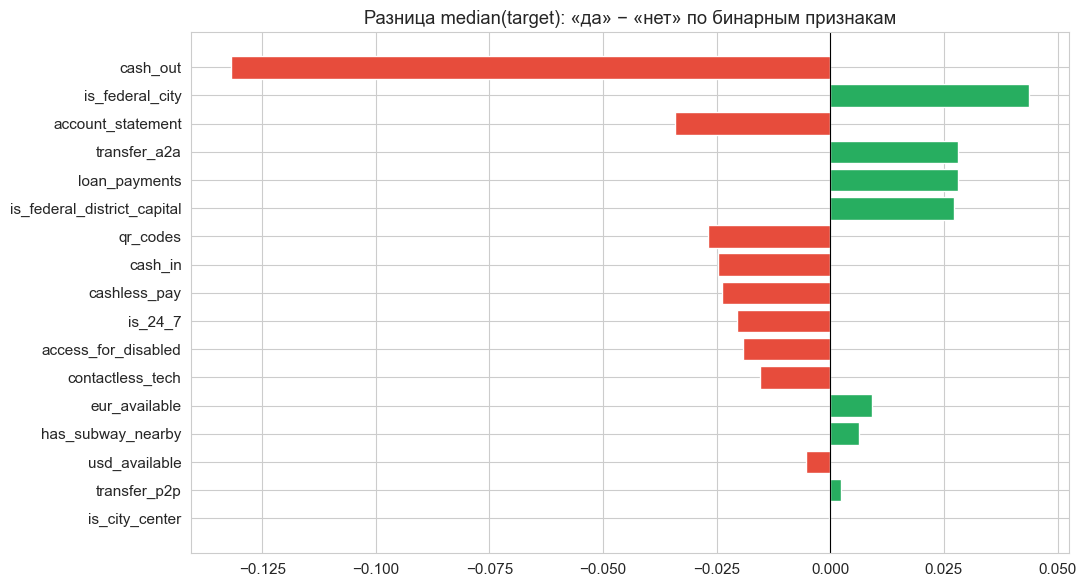

,feature,share_yes_%,median_yes,median_no,diff(yes-no)
6,cash_out,75.400000,-0.026000,0.105800,-0.131800
15,is_federal_city,13.600000,0.022400,-0.021400,0.043800
8,account_statement,35.500000,-0.033500,0.000700,-0.034100
11,transfer_a2a,16.700000,0.006800,-0.021400,0.028200
12,loan_payments,16.900000,0.006800,-0.021400,0.028200
16,is_federal_district_capital,25.400000,0.004700,-0.022500,0.027200
2,qr_codes,21.400000,-0.034500,-0.007700,-0.026900
5,cash_in,56.400000,-0.023400,0.001200,-0.024600
7,cashless_pay,35.300000,-0.029200,-0.005400,-0.023800
0,is_24_7,34.800000,-0.027000,-0.006500,-0.020500


In [23]:
bin_flags = ['is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
             'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
             'transfer_p2p', 'transfer_a2a', 'loan_payments', 'has_subway_nearby',
             'is_city_center', 'is_federal_city', 'is_federal_district_capital']
bin_flags = [c for c in bin_flags if c in df.columns]

rows = []
for c in bin_flags:
    f = pd.to_numeric(df[c].astype('float'), errors='coerce')
    sub = pd.DataFrame({'flag': f, 't': df[TARGET]}).dropna()
    m1 = sub.loc[sub['flag'] == 1, 't'].median()
    m0 = sub.loc[sub['flag'] == 0, 't'].median()
    rows.append({'feature': c, 'share_yes_%': round(sub['flag'].mean() * 100, 1),
                 'median_yes': round(m1, 4) if pd.notna(m1) else np.nan,
                 'median_no': round(m0, 4) if pd.notna(m0) else np.nan,
                 'diff(yes-no)': round(m1 - m0, 4) if pd.notna(m1) and pd.notna(m0) else np.nan})
bin_df = pd.DataFrame(rows).sort_values('diff(yes-no)', key=lambda s: s.abs(), ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#27ae60' if d > 0 else '#e74c3c' for d in bin_df['diff(yes-no)']]
ax.barh(bin_df['feature'][::-1], bin_df['diff(yes-no)'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=.8)
ax.set_title('Разница median(target): «да» − «нет» по бинарным признакам')
plt.tight_layout(); plt.show()
display(bin_df.style.background_gradient(cmap='RdYlGn', subset=['diff(yes-no)']))

Часть функциональных флагов даёт **заметный сдвиг медианы** `target` (например наличие выдачи наличных, бесконтакта, круглосуточности) — это полезный сигнал, который не виден в обычной корреляции. Гео-флаги (`is_city_center`, `is_federal_city`) ожидаемо повышают `target`.

## 16. `atm_group` (банк-владелец) vs target

Статистика target по группам банков:


,count,median,mean,std
atm_group,,,,
8083.0,1040,0.1562,0.1513,0.0484
1942.0,1148,0.0083,0.0042,0.0513
32.0,43,-0.0154,0.0082,0.1063
5478.0,2631,-0.0335,-0.0344,0.0470
3185.5,587,-0.0459,-0.0437,0.0546
496.5,615,-0.0531,-0.0476,0.0513
1022.0,136,-0.0941,-0.0892,0.0342


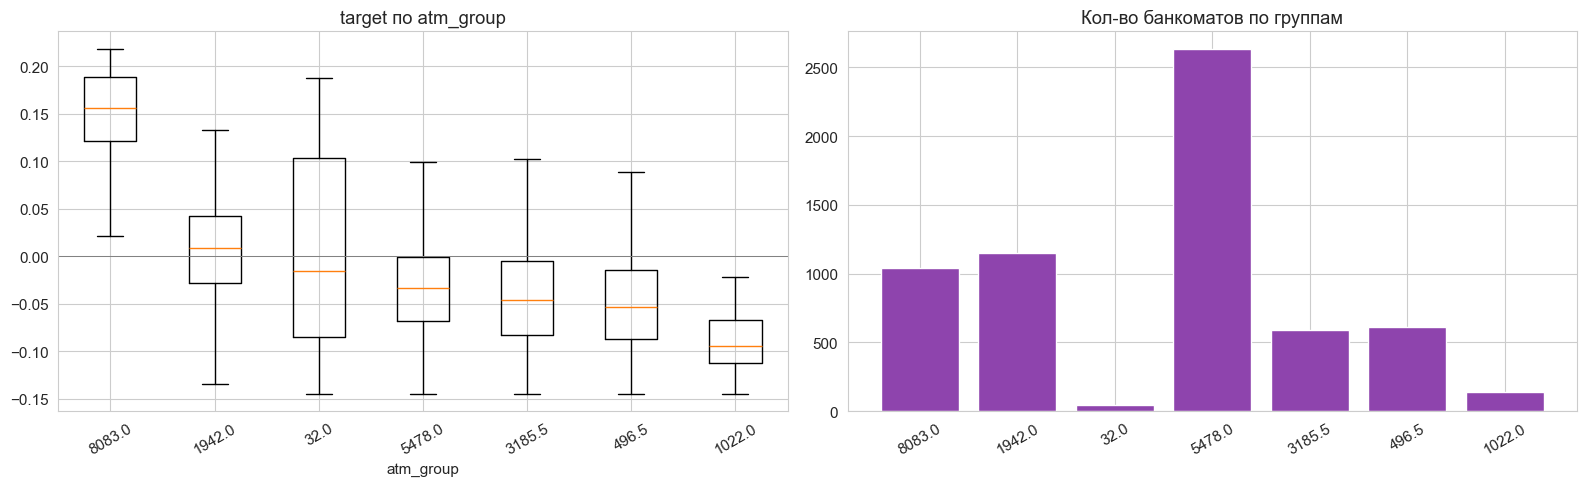

In [24]:
ag = (df.groupby('atm_group')[TARGET].agg(['count', 'median', 'mean', 'std'])
        .round(4).sort_values('median', ascending=False))
print('Статистика target по группам банков:'); display(ag)

order = ag.index.tolist()
data = [df.loc[df['atm_group'] == g, TARGET].dropna().values for g in order]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].boxplot(data, showfliers=False)
ax[0].set_xticks(range(1, len(order) + 1))
ax[0].set_xticklabels([str(g) for g in order], rotation=30)
ax[0].axhline(0, color='gray', lw=.7); ax[0].set_title('target по atm_group'); ax[0].set_xlabel('atm_group')
ax[1].bar([str(g) for g in order], ag['count'].values, color='#8e44ad')
ax[1].tick_params(axis='x', rotation=30); ax[1].set_title('Кол-во банкоматов по группам')
plt.tight_layout(); plt.show()

Медиана `target` **заметно различается между банками** — банк-владелец систематически связан с качеством локации (стратегия размещения). Это сильный сигнал, но он **категориальный**, поэтому в линейные/монотонные корреляции (разделы 8, 14) не попадает — увидим его в mutual information (раздел 18).

## 17. Мультиколлинеарность по всем числовым (старые + новые)

In [25]:
Xc = df.copy()
for c in Xc.columns:
    if Xc[c].dtype == bool: Xc[c] = Xc[c].astype(int)
num = [c for c in Xc.select_dtypes(include=[np.number]).columns
       if c not in ['id', 'geo_lon', 'geo_lat', 'target']]
sp = Xc[num].corr(method='spearman').abs()
np.fill_diagonal(sp.values, 0.0)
pairs = [{'feature_1': a, 'feature_2': b, 'abs_spearman': round(sp.loc[a, b], 3)}
         for i, a in enumerate(sp.columns) for b in sp.columns[i+1:] if sp.loc[a, b] >= 0.8]
redundant = pd.DataFrame(pairs).sort_values('abs_spearman', ascending=False)
print(f'Сильно избыточных пар (|Spearman| >= 0.8): {len(redundant)}')
display(redundant)

Сильно избыточных пар (|Spearman| >= 0.8): 31


,feature_1,feature_2,abs_spearman
1,nearest_subway_dist_m,has_subway_nearby,0.996
0,transfer_a2a,loan_payments,0.987
30,count_landuse_mix_500m,count_landuse_mix_1000m,0.959
6,count_offices_500m,count_offices_1000m,0.953
4,count_offices_300m,count_offices_500m,0.942
24,count_residential_landuse_500m,count_residential_landuse_1000m,0.937
28,count_landuse_mix_300m,count_landuse_mix_500m,0.926
13,count_shops_food_small_500m,count_shops_food_small_1000m,0.912
21,count_residential_landuse_300m,count_residential_landuse_500m,0.886
5,count_offices_300m,count_offices_1000m,0.880


Найденные дубли (например `nearest_subway_dist_m` ↔ `has_subway_nearby`, `count_post_offices_300m` ↔ `nearest_post_offices_dist_m`, `transfer_a2a` ↔ `loan_payments`, счётчики одной категории на соседних радиусах) несут почти одну информацию — кандидаты на прорежение.

## 18. Mutual information — нелинейная зависимость с target

Корреляции (Spearman/Pearson) ловят только монотонную связь и для категориальных почти бесполезны. Mutual information измеряет **любую** статистическую зависимость — здесь это вскрывает признаки, недооценённые корреляцией.

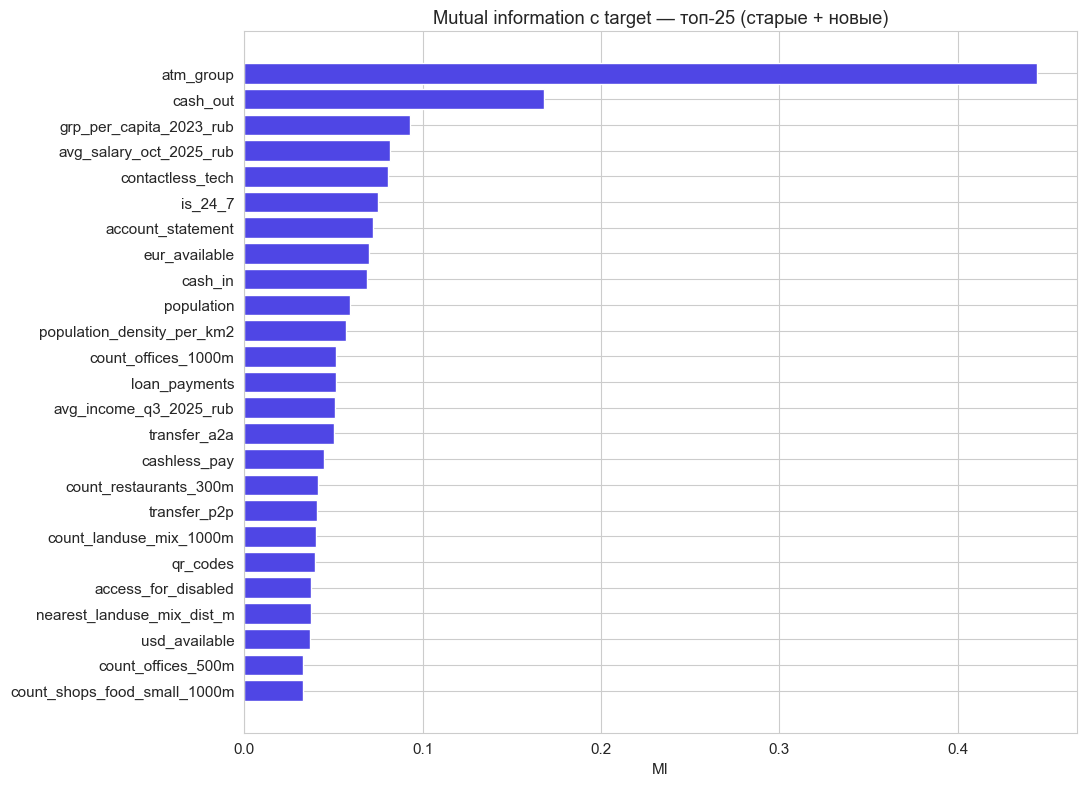

,mutual_info
atm_group,0.4447
cash_out,0.1682
grp_per_capita_2023_rub,0.0931
avg_salary_oct_2025_rub,0.0819
contactless_tech,0.0805
is_24_7,0.0748
account_statement,0.0720
eur_available,0.0697
cash_in,0.0691
population,0.0596


In [26]:
from sklearn.feature_selection import mutual_info_regression

CAT_LIKE = {'atm_group', 'federal_district', 'city_size_category', 'land_use_type',
            'city_type', 'macro_region'}
DROP = ['id', 'geo_lon', 'geo_lat', 'target', 'address_raw', 'address_geocoded',
        'country', 'region', 'municipality', 'city', 'street', 'house']
feat = [c for c in df.columns if c not in DROP]

Xmi = df[feat].copy(); disc = []
for c in Xmi.columns:
    if c in CAT_LIKE or Xmi[c].dtype == object or str(Xmi[c].dtype) == 'category':
        Xmi[c] = Xmi[c].astype('category').cat.codes; disc.append(True)
    elif Xmi[c].dtype == bool:
        Xmi[c] = Xmi[c].astype(int); disc.append(True)
    else:
        Xmi[c] = pd.to_numeric(Xmi[c], errors='coerce'); disc.append(c.startswith('count_'))
Xmi = Xmi.fillna(Xmi.median(numeric_only=True)).fillna(0)
y = df[TARGET].values

mi = pd.Series(mutual_info_regression(Xmi.values, y, discrete_features=disc, random_state=42),
               index=Xmi.columns).sort_values(ascending=False)

top = mi.head(25)
plt.figure(figsize=(11, 8))
plt.barh(top.index[::-1], top.values[::-1], color='#4f46e5')
plt.title('Mutual information с target — топ-25 (старые + новые)'); plt.xlabel('MI')
plt.tight_layout(); plt.show()
display(mi.head(25).round(4).rename('mutual_info').to_frame())

**Главный вывод:** `atm_group` (банк-владелец) — **лидер по MI**, хотя в корреляциях он невидим (категориальный). Далее — функциональные флаги (`cash_out`, `contactless_tech`, `is_24_7`…) и экономика региона, чьё MI выше их же |Spearman| → связь **нелинейная**. Отбор признаков только по корреляции упустил бы самый сильный сигнал; данные требуют моделей, ловящих нелинейности и взаимодействия.

# Итоговые выводы по EDA

## Что предсказываем (target)
`target` — индекс популярности в диапазоне **[-0.145; 0.219]**, **почти симметричный** (mean ≈ 0.001, median ≈ -0.015), слабый правый скос (skew 0.81), без тяжёлых хвостов (kurtosis 0.02), выбросов всего **3.7%**. Это чистая регрессионная цель: метрики RMSE/MAE/R² адекватны, а разбиение на сегменты по знаку прогноза — естественно.

## Главный фактор — банк-владелец (`atm_group`)
- Медиана `target` по банкам разнится **от +0.156 (банк 8083) до -0.094 (банк 1022)** — разброс ≈ 0.25, что **больше стандартного отклонения всего таргета (0.086)**.
- По **mutual information** `atm_group` — безоговорочный лидер (**MI ≈ 0.44**, ~в 2.6 раза выше следующего признака).
- Кто установил банкомат, влияет на популярность сильнее любого отдельного геопризнака — у банков разная стратегия размещения. Признак **категориальный по природе**: высокий Spearman (0.40) на числовых кодах банков — это артефакт кодирования, а не настоящая упорядоченность; честную картину дают boxplot (раздел 16) и MI (раздел 18).

## Экономика региона — сильнейший непрерывный сигнал
Spearman с `target`: **средняя зарплата +0.20**, население +0.15, ВРП на душу +0.14, доходы +0.11 (все p < 0.0001). Богаче и крупнее регион/город → выше популярность. Город федерального значения: median +0.024 против -0.032 у обычных городов; миллионники выше малых.

## Бинарные функции банкомата — нелинейный сигнал
У флагов (`cash_out`, `contactless_tech`, `is_24_7`, `account_statement`…) **высокий MI** (cash_out ≈ 0.17) при **почти нулевой линейной корреляции** — влияние чисто нелинейное/контекстное. Маргинальные медианы «да/нет» сильно **перепутаны с `atm_group`** (например, cash_out по медиане уходит в минус из-за состава банков), поэтому по отдельности эти флаги интерпретировать нельзя — но в совокупности они информативны.

## Локация и инфраструктура — слабо поодиночке
Тип земли: `commercial` чуть выше `residential`/`industrial` (разница медиан < 0.02); `is_city_center` по медиане практически **не разделяет** таргет. POI: все корреляции (дистанции и счётчики) **|r| ≤ 0.13**; чуть заметнее — близость офисов/ресторанов и плотность транспортно-пищевой инфраструктуры. Важна **совокупная насыщенность**, а не отдельный объект.

## Избыточность признаков
**31 пара** с |Spearman| ≥ 0.8: в основном счётчики одной категории на **соседних радиусах** (100/300/500/1000 м), а также `nearest_subway_dist_m` ↔ `has_subway_nearby` (r = 1.0) и `transfer_a2a` ↔ `loan_payments`. Многорадиусные счётчики дублируют друг друга — достаточно **одного компактного радиуса** (~300 м).

## Общий вывод
Линейные/монотонные связи с `target` **слабые** (максимум ≈ 0.20 у зарплаты), но **mutual information** выявляет сильные **нелинейные** сигналы (`atm_group`, функциональные флаги). Признаки информативны, но «работают» во **взаимодействиях** — отбор только по корреляции упустил бы самый сильный фактор (`atm_group`). Данные хорошо подходят для **нелинейных моделей с категориальными признаками**, минимальной трансформацией (логарифм расстояний) и заполнением пропусков; масштабирование не требуется.